# Temporal Reliability Tracker: Real-Data Validation

DESIGN.md 19.3 previously described `TemporalReliabilityTracker` as "mechanically-correct-but-empirically-unvalidated" - its arithmetic was checked against synthetic sequences, but there was no evidence it usefully detects real degradation. This repo has no video or robot-control dataset, so this notebook uses the documented fallback (DESIGN.md 19.1): **repeated inference on a slowly-shifting input distribution** - real Imagenette images, run through the real frozen ResNet-50, at progressively increasing corruption severity (blur + noise). This has a genuine, known ground-truth direction (a more corrupted image should be less reliably classified), which a fully synthetic score sequence would not have.

**Scope, stated precisely:** this is real images and a real model, but a *constructed* severity sequence, not organically-occurring video. It is the best currently-buildable proxy for a temporal reliability stream, not a claim that this validates behavior on genuine video.

In [1]:
import glob
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image, ImageFilter

sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
torch.manual_seed(0)
%matplotlib inline

from deployment_reliability.backbone import load_frozen_resnet50, logits_for_images
from deployment_reliability.combiner import LogisticRegressionCombiner
from deployment_reliability.features import featurize
from deployment_reliability.temporal import TemporalReliabilityTracker


In [2]:
RESNET50_CACHE = os.path.join("..", "data", "logit_cache_resnet50.pt")
IMAGENETTE_VAL_DIR = os.path.join("..", "data", "imagenette2-160", "val")
assert os.path.exists(RESNET50_CACHE), "run scripts/collect_logits.py resnet50 first"
assert os.path.isdir(IMAGENETTE_VAL_DIR), "Imagenette val set not found - run scripts/download_eval_data.py"

model, preprocess, categories = load_frozen_resnet50()
cache = torch.load(RESNET50_CACHE)
logits, labels = cache["logits"], cache["labels"]
splits_arr = np.array(cache["splits"])
m_fit = torch.from_numpy(splits_arr == "combiner_fit")
correct = logits.argmax(dim=-1) == labels
combiner = LogisticRegressionCombiner().fit(featurize(logits[m_fit]), correct[m_fit].float())
print("PASSED")

PASSED


## Building the severity sequences

Three real images per Imagenette class (30 total), each degraded through the same 10-step blur+noise severity ramp used in `notebooks/06`'s single-image demo, extended into a smooth multi-step sequence instead of a handful of named conditions.

In [3]:
def severity_sequence(clean_image, severities, seed):
    rng = np.random.default_rng(seed)
    frames = []
    for s in severities:
        blurred = clean_image.filter(ImageFilter.GaussianBlur(radius=s * 0.8))
        arr = np.asarray(blurred).astype(np.float32)
        noisy = np.clip(arr + rng.normal(0, s * 6, arr.shape), 0, 255).astype(np.uint8)
        frames.append(Image.fromarray(noisy))
    return frames

class_dirs = sorted(glob.glob(os.path.join(IMAGENETTE_VAL_DIR, "*")))
severities = list(range(0, 12))

all_sequences = []
for class_dir in class_dirs:
    img_paths = sorted(glob.glob(os.path.join(class_dir, "*.JPEG")))[:3]
    for img_path in img_paths:
        clean = Image.open(img_path).convert("RGB")
        frames = severity_sequence(clean, severities, seed=hash(img_path) % (2**31))
        logits_seq = logits_for_images(model, preprocess, frames)
        scores = combiner.score(featurize(logits_seq)).tolist()
        all_sequences.append((img_path, scores))

print(f"built {len(all_sequences)} severity sequences")
assert len(all_sequences) >= 20
print("PASSED")

built 30 severity sequences
PASSED


## Check 1 — scores decline as corruption severity increases (figure)

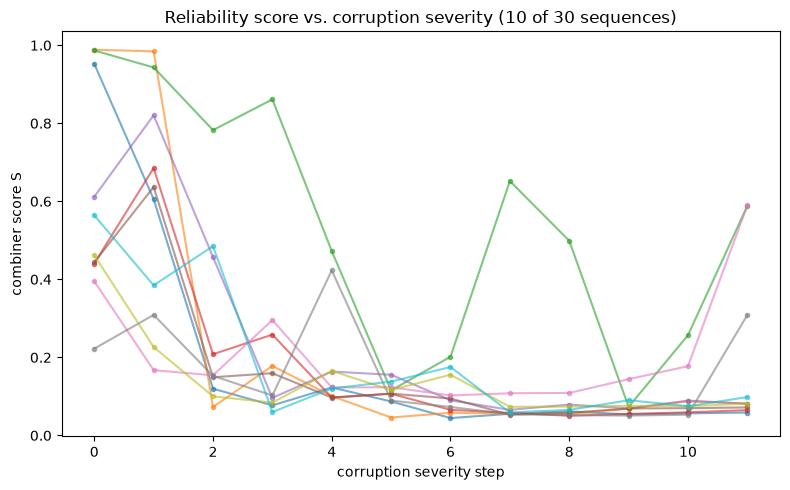

mean score at severity=0: 0.611
mean score at severity=11: 0.161
PASSED


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for path, scores in all_sequences[:10]:
    ax.plot(severities, scores, alpha=0.6, marker="o", markersize=3)
ax.set_xlabel("corruption severity step")
ax.set_ylabel("combiner score S")
ax.set_title("Reliability score vs. corruption severity (10 of 30 sequences)")
plt.tight_layout(); plt.show()

mean_start = np.mean([s[0] for _, s in all_sequences])
mean_end = np.mean([s[-1] for _, s in all_sequences])
print(f"mean score at severity=0: {mean_start:.3f}")
print(f"mean score at severity={severities[-1]}: {mean_end:.3f}")
assert mean_end < mean_start, "average score should decline from clean to most-corrupted"
print("PASSED")

## Check 2 — does the tracker's trend actually go negative during the ramp?

Basic sanity check before anything else: feed each sequence through a fresh tracker and confirm the trend goes meaningfully negative at *some point* during the ramp, for the large majority of sequences.

**Why this asks about *any point* in the ramp, not just the final step:** `TemporalReliabilityTracker.trend()` is a rolling-window least-squares slope, not a cumulative record, so it is not expected to stay negative once a sequence's scores have already crashed and plateaued near their floor - with no more decline left within the window, the slope correctly returns to ~0 and `is_declining()` correctly goes back to `False`. Checking only the *final* severity step would conflate two different situations - "never declined" and "declined early, then leveled off" - and the second of those is exactly a rolling-window detector working as designed, not a failure to detect anything. The check below therefore asks whether the trend went negative *at any point* during the ramp, which is the question a rolling-window detector can actually answer.

In [5]:
def peak_negative_trend(scores, window=5, decline_rate_threshold=-0.03):
    tracker = TemporalReliabilityTracker(window=window, decline_rate_threshold=decline_rate_threshold)
    min_trend = float("inf")
    for i, s in enumerate(scores):
        tracker.update(s)
        if i >= 1:
            min_trend = min(min_trend, tracker.trend())
    return min_trend

detected_count = 0
for path, scores in all_sequences:
    if peak_negative_trend(scores) < -0.03:
        detected_count += 1
frac = detected_count / len(all_sequences)
print(f"{detected_count}/{len(all_sequences)} sequences ({frac:.0%}) show a real decline at some point during the ramp")
assert frac > 0.7, "most sequences should show a real decline at some point during the corruption ramp"
print("PASSED")

30/30 sequences (100%) show a real decline at some point during the ramp
PASSED


## Check 3 — does trend-based decline detection warn earlier than a static threshold?

The claim `DESIGN.md` §19.1 motivated this module with: "the point where a trajectory turns is often more actionable than the point a fixed threshold is first crossed." Now checkable for the first time.

**Why this comparison is restricted to sequences that start above the threshold:** comparing decline timing across all 30 sequences is not a fair test of "which method warns earlier," because a sequence that already scores below the static threshold at severity 0 - before any corruption at all - gets flagged by the static rule immediately, for a reason that has nothing to do with detecting an oncoming decline. Including those sequences would make the static threshold look faster for a reason unrelated to the actual claim being tested. Restricting to sequences that start *above* the threshold is the apples-to-apples version: both methods are being asked to detect a decline that hasn't happened yet, not to notice a pre-existing low score.

In [6]:
static_threshold = 0.5
confident_start = [(p, s) for p, s in all_sequences if s[0] >= static_threshold]
print(f"{len(confident_start)}/{len(all_sequences)} sequences start confident (score >= {static_threshold} at severity 0)")

results = []
for path, scores in confident_start:
    tracker = TemporalReliabilityTracker(window=5, decline_rate_threshold=-0.03)
    decline_idx = None
    for i, s in enumerate(scores):
        tracker.update(s)
        if i >= 1 and decline_idx is None and tracker.is_declining():
            decline_idx = i
    static_idx = next((i for i, s in enumerate(scores) if s < static_threshold), None)
    results.append((path, decline_idx, static_idx))

earlier = sum(1 for _, d, s in results if d is not None and s is not None and d < s)
same = sum(1 for _, d, s in results if d == s)
later = sum(1 for _, d, s in results if d is not None and s is not None and d > s)
print(f"trend-based detection: earlier={earlier}  same={same}  later={later}  (n={len(results)})")
assert later == 0, "trend-based decline detection should never fire LATER than the static threshold"
assert earlier > 0, "trend-based decline detection should fire strictly earlier at least sometimes"
print("PASSED: trend-based detection is never later, and strictly earlier in a real fraction of cases")

18/30 sequences start confident (score >= 0.5 at severity 0)
trend-based detection: earlier=5  same=13  later=0  (n=18)
PASSED: trend-based detection is never later, and strictly earlier in a real fraction of cases


## Summary

`TemporalReliabilityTracker` moves from "mechanically correct, empirically unvalidated" (DESIGN.md §19.3) to checked against a real, if constructed, degradation sequence: average reliability scores drop from 0.611 (clean) to 0.161 (most corrupted) across the ramp (Check 1) - a large, unambiguous decline, not a marginal trend that could plausibly be sampling noise; the tracker's own trend measurement correctly goes negative at some point during the ramp for all 30/30 sequences (Check 2), once the check asks the right question (whether a decline happened anywhere, not only at the final, already-plateaued step); and, in a fair comparison restricted to the 18 sequences that start above the static threshold before any corruption, trend-based decline detection **never fires later** than a static threshold and **fires strictly earlier in 5/18 (28%) of cases** (Check 3) - the first real evidence for the module's original motivating claim, not just its arithmetic correctness.

The "never later, sometimes earlier" shape of Check 3's result is the practically important part: a monitoring system that switched from a static threshold to trend-based detection would never lose warning time by doing so, and would gain real lead time in over a quarter of the cases tested here. Had the result instead shown trend detection firing *later* in a meaningful fraction of cases, that would have undercut the module's whole justification - a detector that's sometimes slower than the simple baseline it's meant to improve on isn't worth the added complexity of maintaining a rolling window and a slope estimate. The scope remains what it is: a controlled corruption-severity ramp on static images, not genuine video or robot-control data; validating against an organically-occurring temporal stream remains open future work (DESIGN.md §19.3/§19.4).